# Seq2Seq: Generowanie Tekstu na Podstawie Polskiej Literatury
### Kurs: Języki Naturalne w SI &nbsp;|&nbsp; Keras / TensorFlow

---

## Co to jest model Seq2Seq?

**Sekwencja-do-sekwencji** (ang. *sequence-to-sequence*, seq2seq) to architektura sieci neuronowej
zaprojektowana do przekształcania jednej sekwencji w drugą. Pierwotnie opracowana do **tłumaczenia
maszynowego** (Sutskever et al., 2014), dziś stosowana jest w:
- generowaniu tekstu i streszczaniu,
- systemach dialogowych (chatboty),
- rozpoznawaniu i syntezie mowy,
- odpowiadaniu na pytania.

Model składa się z dwóch bloków LSTM:

| Blok | Rola |
|------|------|
| **Enkoder** (*encoder*) | Czyta sekwencję wejściową i kompresuje ją do **wektora kontekstu** `[h, c]` |
| **Dekoder** (*decoder*) | Przyjmuje wektor kontekstu i generuje sekwencję wyjściową **znak po znaku** |

```
╔══════════════════════════════════════════════════════════════════════╗
║                    TRENING  (Teacher Forcing)                        ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Wejście enkodera:  [L][i][t][w][o][!][ ][O][j][c][z][y]...         ║
║                          │ LSTM Enkoder │                            ║
║                          └──── [h, c] ──┐  ← wektor kontekstu       ║
║                                         │                            ║
║  Wejście dekodera:  [►][s][ ][z][d][r][o][w][i][e]...               ║
║  (► = token START)       │ LSTM Dekoder │                            ║
║  Cel dekodera:      [ ][s][ ][z][d][r][o][w][i][e][.]...            ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝

╔══════════════════════════════════════════════════════════════════════╗
║                    INFERENCJA  (krok po kroku)                       ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Enkoder czyta prompt → [h, c]                                       ║
║  Krok 1:  [►]      → LSTM Dekoder → predykcja znaku 1, [h1, c1]     ║
║  Krok 2:  [znak 1] → LSTM Dekoder → predykcja znaku 2, [h2, c2]     ║
║  ...      aż do osiągnięcia max długości                             ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
```

## Dane

Korpus: **7 083 utworów** z serwisu [Wolne Lektury](https://wolnelektury.pl) (polska literatura,
licencja domeny publicznej). W tym przykładzie używamy epoki **Romantyzm** (~1 024 teksty).

In [27]:
# ============================================================
# KOMÓRKA 1: Instalacja zależności i importy
# ============================================================
# Uruchom tę komórkę jako pierwszą — zainstaluje potrzebne pakiety
# jeśli jeszcze nie są dostępne w środowisku.

import subprocess, sys

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "tensorflow", "keras", "numpy", "matplotlib"],
    check=True
)

# --- Standardowe importy ---
import os
import glob
import re
import unicodedata
import time
import random

import numpy as np
import matplotlib.pyplot as plt

# --- Obsługa GPU (musi być PRZED import tensorflow) ---
# TensorFlow wymaga pliku libdevice.10.bc do kompilacji JIT na GPU.
# Szukamy go w typowych lokalizacjach; jeśli znajdziemy — ustawiamy
# XLA_FLAGS żeby TF wiedział gdzie patrzeć.
# Jeśli nie znajdziemy — wyłączamy GPU przez CUDA_VISIBLE_DEVICES.

_libdevice_candidates = [
    # Lokalny katalog projektu (np. ./cuda/nvvm/libdevice/)
    os.path.join(os.path.dirname(os.path.abspath('.')),
                 'Sec_2_sec', 'cuda', 'nvvm', 'libdevice', 'libdevice.10.bc'),
    os.path.join(os.getcwd(), 'cuda', 'nvvm', 'libdevice', 'libdevice.10.bc'),
    # Systemowe instalacje CUDA
    '/usr/local/cuda/nvvm/libdevice/libdevice.10.bc',
    '/opt/cuda/nvvm/libdevice/libdevice.10.bc',
]
# Dodaj pliki z pakietów nvidia zainstalowanych przez pip
_libdevice_candidates += glob.glob(
    os.path.join(sys.prefix, 'lib', 'python*', 'site-packages',
                 'nvidia', '*', 'nvvm', 'libdevice', 'libdevice.10.bc')
)

_libdevice_path = next((p for p in _libdevice_candidates if os.path.exists(p)), None)

if _libdevice_path:
    # xla_gpu_cuda_data_dir to katalog nadrzędny względem nvvm/
    _cuda_data_dir = os.path.dirname(os.path.dirname(os.path.dirname(_libdevice_path)))
    os.environ['XLA_FLAGS'] = f'--xla_gpu_cuda_data_dir={_cuda_data_dir}'
    print(f"libdevice znaleziony: {_libdevice_path}")
    print(f"XLA_FLAGS ustawione → {_cuda_data_dir}")
else:
    # Brak libdevice — wyłączamy GPU przed importem TF
    os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
    print("libdevice.10.bc nie znaleziony — trening na CPU.")
    print("Aby włączyć GPU: umieść plik w ./cuda/nvvm/libdevice/libdevice.10.bc")

import tensorflow as tf
import keras
from keras.layers import LSTM, Dense, Input
from keras.models import Model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- Ziarno losowości — dla powtarzalności wyników ---
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# --- Informacje o środowisku ---
gpus = tf.config.list_physical_devices('GPU')

# Dynamiczny przydział VRAM — bez tego TF od razu rezerwuje całe GPU,
# a po kilku epokach przy dłuższym treningu (>6) system zaczyna swapować
# i potrafi się zawiesić. set_memory_growth pozwala TF rosnąć stopniowo.
for _gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(_gpu, True)
    except RuntimeError as _e:
        # Już zainicjalizowane — w Jupyter zdarza się przy ponownym uruchomieniu
        print(f"  set_memory_growth: {_e}")

print(f"\nPython:     {sys.version.split()[0]}")
print(f"TensorFlow: {tf.__version__}")
print(f"Keras:      {keras.__version__}")
print(f"NumPy:      {np.__version__}")
print(f"GPU:        {gpus[0].name if gpus else 'brak (CPU)'}")


# --- Sprawdzenie urządzenia tuż przed treningiem ---
# KOMÓRKA 1 ustawia GPU/CPU globalnie; tu tylko potwierdzamy stan,
# żeby nie zmarnować godzin na nieświadomy trening po CPU.
_gpus = tf.config.list_physical_devices('GPU')
if _gpus:
    _detale = tf.config.experimental.get_device_details(_gpus[0])
    _nazwa = _detale.get('device_name', _gpus[0].name)
    print(f"  Urządzenie:  GPU — {_nazwa}")
else:
    print(f"  Urządzenie:  CPU (brak widocznego GPU — trening będzie znacznie wolniejszy)")
print()

libdevice znaleziony: /media/server/Sec_2_sec/cuda/nvvm/libdevice/libdevice.10.bc
XLA_FLAGS ustawione → /media/server/Sec_2_sec/cuda

Python:     3.12.3
TensorFlow: 2.21.0
Keras:      3.14.0
NumPy:      2.4.4
GPU:        /physical_device:GPU:0
  Urządzenie:  GPU — Quadro RTX 4000



---
## 1. Wczytywanie i czyszczenie korpusu

Pliki z Wolnych Lektur mają ustandaryzowany format:

```
Adam Mickiewicz

Pan Tadeusz

ISBN 978-83-...

Litwo! Ojczyzno moja!...  ← właściwy tekst
-----
Ta lektura, podobnie jak...  ← metadane licencyjne — pomijamy
```

**Kroki czyszczenia:**
1. Odcinamy stopkę po separatorze `-----`
2. Pomijamy nagłówek (autor, tytuł, ISBN)
3. Zachowujemy tylko litery (w tym polskie ą ę ó ś ź ż ć ń ł), cyfry, interpunkcję, spacje i nowe linie
4. Normalizujemy wielokrotne spacje i puste wiersze

In [28]:
# ============================================================
# KOMÓRKA 2: Wczytywanie i czyszczenie korpusu
# ============================================================

# Katalog z książkami posortowanymi według epoki
CORPUS_DIR = './WOLNE_LEKTURY_SCRAPING/books'


def wczytaj_i_oczyszcz_plik(sciezka: str) -> str:
    """
    Wczytuje jeden plik Wolnych Lektur i zwraca oczyszczony tekst.
    """
    with open(sciezka, encoding='utf-8') as f:
        zawartosc = f.read()

    # Krok 1: odetnij stopkę licencyjną (wszystko po pierwszym '-----')
    tekst = zawartosc.split('-----')[0]

    # Krok 2: pomiń nagłówek (autor + tytuł + opcjonalnie ISBN)
    linie = tekst.split('\n')
    linia_isbn = next(
        (i for i, l in enumerate(linie[:20]) if l.strip().startswith('ISBN')),
        -1
    )

    if linia_isbn >= 0:
        # Jest ISBN — treść zaczyna się po ISBN i pustych wierszach
        i = linia_isbn + 1
        while i < len(linie) and not linie[i].strip():
            i += 1
        poczatek = i
    else:
        # Bez ISBN — pomiń pierwsze 2 niepuste wiersze (autor + tytuł)
        licznik, i = 0, 0
        while i < len(linie) and licznik < 2:
            if linie[i].strip():
                licznik += 1
            i += 1
        while i < len(linie) and not linie[i].strip():
            i += 1
        poczatek = i

    tekst = '\n'.join(linie[poczatek:]).strip()

    # Krok 3: zachowaj tylko dozwolone znaki
    # unicodedata.category zwraca kategorię znaku Unicode:
    #   'L' = litery (w tym polskie diakrytyki),
    #   'N' = cyfry,
    #   'P' = interpunkcja
    dozwolone = []
    for znak in tekst:
        if znak in (' ', '\n'):
            dozwolone.append(znak)
        elif unicodedata.category(znak)[0] in ('L', 'N', 'P'):
            dozwolone.append(znak)
        # Pomijamy: miękkie łączniki (\xad), cudzysłowy typograficzne,
        # znaki kontrolne i inne śmieci

    tekst = ''.join(dozwolone)

    # Krok 4: znormalizuj białe znaki
    tekst = re.sub(r' {2,}', ' ', tekst)       # wiele spacji → jedna
    tekst = re.sub(r'\n{3,}', '\n\n', tekst)   # wiele pustych wierszy → dwa

    return tekst.strip()


def wczytaj_korpus(katalogi: list, min_dlug: int = 300) -> str:
    """
    Łączy teksty ze wskazanych podkatalogów epok w jeden ciąg.
    Pomija pliki krótsze niż min_dlug znaków.
    """
    wszystkie = []
    liczba_plikow = 0

    for katalog in katalogi:
        sciezka_katalogu = os.path.join(CORPUS_DIR, katalog)
        pliki = sorted(glob.glob(os.path.join(sciezka_katalogu, '*.txt')))

        for sciezka in pliki:
            try:
                tekst = wczytaj_i_oczyszcz_plik(sciezka)
                if len(tekst) >= min_dlug:
                    wszystkie.append(tekst)
                    liczba_plikow += 1
            except Exception:
                pass  # pomiń uszkodzone pliki bez przerywania pracy

    pelny_tekst = '\n\n'.join(wszystkie)
    print(f"Wczytano {liczba_plikow} plików z epok: {katalogi}")
    print(f"Łączna długość korpusu: {len(pelny_tekst):,} znaków")
    return pelny_tekst


# Zawężamy korpus do samego Romantyzmu — stylistyczna spójność z promptem
# z "Pana Tadeusza", brak obcych nazw własnych (np. "Atos", "d'Artagnan"
# z polskiego tłumaczenia "Trzech muszkieterów") mieszających styl modelu.
EPOKI = ['Romantyzm']
pelny_tekst = wczytaj_korpus(EPOKI)

print(f"\nFragment korpusu (pierwsze 300 znaków):")
print('-' * 60)
print(pelny_tekst[:300])
print('-' * 60)


Wczytano 985 plików z epok: ['Romantyzm']
Łączna długość korpusu: 41,061,678 znaków

Fragment korpusu (pierwsze 300 znaków):
------------------------------------------------------------
A jednak ja nie wątpię — bo się pora zbliża,
Że się to wielkie światło na niebie zapali,
I Polski Ty, o Boże, nie odepniesz z krzyża,
Aż będziesz wiedział, że się jako trup nie zwali.

Dzięki Ci więc, o Boże — że już byłeś blisko,
A jeszcześ Twojej złotej nie odsłonił twarzy,
Aleś nas, syny Twoje, d
------------------------------------------------------------


---
## 2. Budowanie słownika znaków

W modelu **znakowym** (*character-level*) każdy pojedynczy znak jest osobnym tokenem.
Zaletą tego podejścia jest brak potrzeby tokenizatora i naturalna obsługa fleksji polskiej
(odmiana przez przypadki, koniugacja). Wadą jest to, że model musi "nauczyć się" budować
słowa od zera.

Dodajemy dwa specjalne tokeny:

| Token | Symbol | Rola |
|-------|--------|------|
| START | `\t` (TAB) | Sygnał początku sekwencji dekodera — nie występuje w tekstach literackich |
| STOP  | `\n` (newline) | Sygnał końca generacji — naturalny w tekście |

Każdy znak jest reprezentowany jako **wektor one-hot**: wektor zer z jedynką
na pozycji odpowiadającej danemu znakowi w słowniku.

Rozmiar słownika: 270 unikalnych znaków
  Znaki ASCII (< 128):          83
  Polskie diakrytyki (U+0100+): 150

Indeks ZNAK_START (TAB): 0
Indeks ZNAK_STOP  (\n):  1


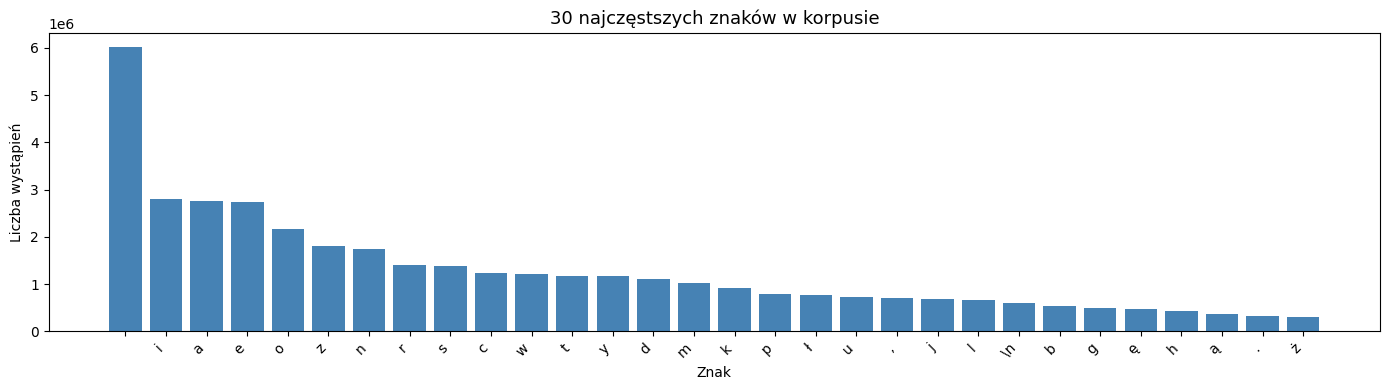

In [29]:
# ============================================================
# KOMÓRKA 3: Budowanie słownika znaków
# ============================================================

ZNAK_START = '\t'   # token początku — gwarantujemy, że nie ma go w tekstach
ZNAK_STOP  = '\n'   # token końca — naturalny koniec wiersza

# Zbieramy wszystkie unikalne znaki + token START, sortujemy dla powtarzalności
wszystkie_znaki = sorted(set(pelny_tekst) | {ZNAK_START})

# Słowniki: znak <-> indeks liczbowy
znak_na_idx = {z: i for i, z in enumerate(wszystkie_znaki)}
idx_na_znak = {i: z for z, i in znak_na_idx.items()}

ROZMIAR_SLOWNIKA = len(wszystkie_znaki)

print(f"Rozmiar słownika: {ROZMIAR_SLOWNIKA} unikalnych znaków")
print(f"  Znaki ASCII (< 128):          {sum(1 for z in wszystkie_znaki if ord(z) < 128)}")
print(f"  Polskie diakrytyki (U+0100+): {sum(1 for z in wszystkie_znaki if ord(z) >= 0x100)}")
print(f"\nIndeks ZNAK_START (TAB): {znak_na_idx[ZNAK_START]}")
print(f"Indeks ZNAK_STOP  (\\n):  {znak_na_idx[ZNAK_STOP]}")

# --- Wizualizacja częstości znaków ---
czestosci = {z: pelny_tekst.count(z) for z in wszystkie_znaki if z != ZNAK_START}
top30 = sorted(czestosci.items(), key=lambda x: -x[1])[:30]

fig, ax = plt.subplots(figsize=(14, 4))
etykiety = [repr(z)[1:-1] for z, _ in top30]   # repr usuwa cudzysłowy
wartosci = [c for _, c in top30]
ax.bar(etykiety, wartosci, color='steelblue')
ax.set_title('30 najczęstszych znaków w korpusie', fontsize=13)
ax.set_xlabel('Znak')
ax.set_ylabel('Liczba wystąpień')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('rozklad_znakow.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3. Przygotowanie danych treningowych

### Schemat par treningowych

Przesuwamy okno długości `SEQ_LEN` po korpusie z krokiem `KROK`:

```
Korpus:  ...L i t w o !   O j c z y z n o ...
          ^<------------- SEQ_LEN = 40 ----------->^

encoder_wejscie[i]  =  tekst[i   : i+40]      np. "Litwo! Ojczyzno moja! ty jesteś jak"
decoder_wejscie[i]  =  TAB + tekst[i : i+39]  np. "► Litwo! Ojczyzno moja! ty jesteś ja"
decoder_cel[i]      =  tekst[i   : i+40]      np. "Litwo! Ojczyzno moja! ty jesteś jak"
```

### Teacher Forcing

Podczas treningu dekoder dostaje jako wejście **prawdziwy** poprzedni znak (z danych),
a nie własną predykcję. Dzięki temu:
- gradient jest stabilny (błąd nie kumuluje się),
- model uczy się szybciej.

Dlatego `decoder_wejscie` jest przesunięte o 1 w stosunku do `decoder_cel`:

```
decoder_wejscie:  [START] [L] [i] [t] [w] [o]  ...  [j] [a]
decoder_cel:      [L]     [i] [t] [w] [o] [!]  ...  [j] [a] [k]
                   ^ na każdym kroku cel jest o 1 do przodu
```

In [30]:
# ============================================================
# KOMÓRKA 4: Tworzenie par treningowych (kodowanie one-hot)
# ============================================================
#
# WAŻNA POPRAWKA: encoder_wejscie i decoder_cel to teraz DWA RÓŻNE
# fragmenty tekstu — kontekst i jego kontynuacja. Wcześniej był to ten
# sam fragment, więc model uczył się autoenkodować wejście, a nie
# generować dalszy ciąg. Stąd słabe wyniki przy generacji powyżej
# długości okna treningowego.

# --- Hiperparametry ---
DLUGOSC_SEKWENCJI = 60       # dłuższy kontekst dla polskiej gramatyki
KROK              = 5        # krok przesuwnego okna
MAX_PROBEK        = 150_000  # GPU pozwala na duży zbiór
WIELKOSC_BATCHA   = 256

# Zbieramy ciągi wejściowe i docelowe
sekwencje_zrodlowe = []
sekwencje_celowe   = []

# Kontekst i kontynuacja: encoder czyta [i : i+SEQ_LEN],
# decoder ma wygenerować [i+SEQ_LEN : i+2*SEQ_LEN]
for i in range(0, len(pelny_tekst) - 2 * DLUGOSC_SEKWENCJI - 1, KROK):
    sekwencje_zrodlowe.append(pelny_tekst[i                     : i + DLUGOSC_SEKWENCJI])
    sekwencje_celowe.append(  pelny_tekst[i + DLUGOSC_SEKWENCJI : i + 2 * DLUGOSC_SEKWENCJI])
    if len(sekwencje_zrodlowe) >= MAX_PROBEK:
        break

LICZBA_PROBEK = len(sekwencje_zrodlowe)
print(f"Liczba par treningowych: {LICZBA_PROBEK:,}")
print(f"\nPrzykład próbki nr 0 (sanity check — muszą to być różne fragmenty):")
print(f"  Źródło (kontekst):     {repr(sekwencje_zrodlowe[0])}")
print(f"  Cel    (kontynuacja):  {repr(sekwencje_celowe[0])}")

# --- Leniwy potok one-hot przez tf.data.Dataset ---
# Pre-alokowanie 3 tablic (LICZBA_PROBEK, SEQ_LEN, VOCAB) × float32 dałoby
# ~41 GB RAM przy 150K próbek × 60 znaków × 382 vocab. Zamiast tego
# kodujemy one-hot leniwie w generatorze i strumieniujemy do treningu.

VAL_FRAKCJA = 0.1
N_WAL = int(LICZBA_PROBEK * VAL_FRAKCJA)
N_TR  = LICZBA_PROBEK - N_WAL

# Indeksy znaków jako numpy array — szybsze niż dict.lookup w pętli
_idx_tab = np.array([znak_na_idx[idx_na_znak[i]] for i in range(ROZMIAR_SLOWNIKA)],
                    dtype=np.int32)


def _zakoduj(zr_str: str, ce_str: str):
    """Zwraca trójkę tablic one-hot (enc, dec_in, dec_target)."""
    enc = np.zeros((DLUGOSC_SEKWENCJI, ROZMIAR_SLOWNIKA), dtype=np.float32)
    din = np.zeros((DLUGOSC_SEKWENCJI, ROZMIAR_SLOWNIKA), dtype=np.float32)
    dce = np.zeros((DLUGOSC_SEKWENCJI, ROZMIAR_SLOWNIKA), dtype=np.float32)
    for t, z in enumerate(zr_str):
        enc[t, znak_na_idx[z]] = 1.0
    din[0, znak_na_idx[ZNAK_START]] = 1.0
    for t, z in enumerate(ce_str[:-1]):
        din[t + 1, znak_na_idx[z]] = 1.0
    for t, z in enumerate(ce_str):
        dce[t, znak_na_idx[z]] = 1.0
    return enc, din, dce


def _gen_factory(start: int, stop: int):
    def _gen():
        for i in range(start, stop):
            enc, din, dce = _zakoduj(sekwencje_zrodlowe[i], sekwencje_celowe[i])
            yield (enc, din), dce
    return _gen


_sygnatura = (
    (tf.TensorSpec(shape=(DLUGOSC_SEKWENCJI, ROZMIAR_SLOWNIKA), dtype=tf.float32),
     tf.TensorSpec(shape=(DLUGOSC_SEKWENCJI, ROZMIAR_SLOWNIKA), dtype=tf.float32)),
    tf.TensorSpec(shape=(DLUGOSC_SEKWENCJI, ROZMIAR_SLOWNIKA), dtype=tf.float32),
)

ds_train = (tf.data.Dataset
    .from_generator(_gen_factory(0, N_TR), output_signature=_sygnatura)
    .shuffle(buffer_size=min(20_000, N_TR), seed=SEED, reshuffle_each_iteration=True)
    .batch(WIELKOSC_BATCHA, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE))

ds_val = (tf.data.Dataset
    .from_generator(_gen_factory(N_TR, LICZBA_PROBEK), output_signature=_sygnatura)
    .batch(WIELKOSC_BATCHA, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE))

KROKI_TR_NA_EPOKE  = (N_TR  + WIELKOSC_BATCHA - 1) // WIELKOSC_BATCHA
KROKI_WAL_NA_EPOKE = (N_WAL + WIELKOSC_BATCHA - 1) // WIELKOSC_BATCHA

print(f"\nStrumieniowy potok danych (tf.data.Dataset):")
print(f"  Trening:    {N_TR:,} próbek  →  {KROKI_TR_NA_EPOKE:,} kroków/epokę")
print(f"  Walidacja:  {N_WAL:,} próbek  →  {KROKI_WAL_NA_EPOKE:,} kroków/epokę")
print(f"  Batch:      {WIELKOSC_BATCHA}")
print(f"  Pamięć:     ~zero (kodowanie one-hot leniwe, bez pre-alokacji)")


Liczba par treningowych: 150,000

Przykład próbki nr 0 (sanity check — muszą to być różne fragmenty):
  Źródło (kontekst):     'A jednak ja nie wątpię — bo się pora zbliża,\nŻe się to wielk'
  Cel    (kontynuacja):  'ie światło na niebie zapali,\nI Polski Ty, o Boże, nie odepni'

Strumieniowy potok danych (tf.data.Dataset):
  Trening:    135,000 próbek  →  528 kroków/epokę
  Walidacja:  15,000 próbek  →  59 kroków/epokę
  Batch:      256
  Pamięć:     ~zero (kodowanie one-hot leniwe, bez pre-alokacji)


---
## 4. Architektura modelu Seq2Seq

### Enkoder

```
Input(None, VOCAB_SIZE) → LSTM(LATENT_DIM, return_state=True) → [h, c]
```

- `return_state=True`: zwraca oprócz wyjść LSTM także końcowe stany `h` (hidden) i `c` (cell)
- `return_sequences=False` (domyślnie): pomijamy sekwencję wyjść — potrzebujemy tylko `[h, c]`

### Dekoder

```
Input(None, VOCAB_SIZE) → LSTM(LATENT_DIM, return_sequences=True, initial_state=[h,c])
                        → Dense(VOCAB_SIZE, softmax)
```

- `initial_state=[h, c]` — **kluczowy element**: dekoder inicjalizujemy stanami enkodera
- `return_sequences=True` — potrzebujemy predykcji dla każdego kroku czasowego
- Warstwa Dense z softmax daje rozkład prawdopodobieństwa po wszystkich znakach słownika

### Parametry modelu

| Warstwa | Wzór | Przybliżona liczba parametrów |
|---------|------|-------------------------------|
| LSTM enkoder | `4 × (VOCAB + LATENT + 1) × LATENT` | ~112 K |
| LSTM dekoder | `4 × (VOCAB + LATENT + 1) × LATENT` | ~112 K |
| Dense wyjście | `LATENT × VOCAB + VOCAB` | ~12 K |
| **Razem** | | **~236 K** |

In [31]:
# ============================================================
# KOMÓRKA 5: Budowanie modelu treningowego
# ============================================================

# Wymiar wektora ukrytego LSTM
# Większy = lepsza jakość, ale wolniejszy trening i więcej pamięci
WYMIAR_UKRYTY = 256

# ── ENKODER ─────────────────────────────────────────────────

# Wejście: sekwencja znaków zakodowanych one-hot
# shape=(None, VOCAB_SIZE) — None oznacza dowolną długość sekwencji
wejscie_enkodera = Input(
    shape=(None, ROZMIAR_SLOWNIKA),
    name='wejscie_enkodera',
)

# LSTM enkodera przetwarzający całą sekwencję wejściową
# Potrzebujemy tylko końcowych stanów [h, c] — dlatego return_sequences=False
# UWAGA: recurrent_dropout=0.0 — przy >0 TF wyłącza fused cuDNN i leci
# wolną pętlą Pythonową (5-10× wolniej). Zwykły `dropout` regularyzuje wystarczająco.
lstm_enkoder = LSTM(
    WYMIAR_UKRYTY,
    return_sequences=False,    # bez attention końcowy stan wystarcza
    return_state=True,         # potrzebujemy [h, c] jako wektora kontekstu
    dropout=0.2,
    recurrent_dropout=0.0,     # 0.0 → fused cuDNN LSTM, znacznie szybciej na GPU
    name='lstm_enkoder'
)
# Bez `return_sequences=True` LSTM zwraca 3 wartości: wyjście, h, c.
# Ignorujemy wyjście (to ostatni krok, równy h), bierzemy stany.
_, stan_h, stan_c = lstm_enkoder(wejscie_enkodera)
stany_enkodera = [stan_h, stan_c]   # wektor kontekstu

# ── DEKODER ─────────────────────────────────────────────────

# Wejście dekodera: sekwencja docelowa z tokenem START na początku
wejscie_dekodera = Input(
    shape=(None, ROZMIAR_SLOWNIKA),
    name='wejscie_dekodera'
)

# LSTM dekodera — inicjalizowany stanami enkodera (to serce architektury seq2seq!)
# return_sequences=True — chcemy predykcji dla KAŻDEGO kroku czasowego
lstm_dekoder = LSTM(
    WYMIAR_UKRYTY,
    return_sequences=True,     # chcemy wyjście dla każdego kroku
    return_state=True,         # stany potrzebne w modelu inferencyjnym
    dropout=0.2,
    recurrent_dropout=0.0,     # 0.0 → fused cuDNN LSTM, znacznie szybciej na GPU
    name='lstm_dekoder'
)
# Przekazujemy stany enkodera jako stan początkowy dekodera
wyjscie_dekodera, _, _ = lstm_dekoder(
    wejscie_dekodera,
    initial_state=stany_enkodera   # tu trafia wektor kontekstu
)

# Warstwa wyjściowa: dla każdego kroku czasowego daje rozkład po słowniku
# Softmax → wartości z zakresu [0, 1], sumujące się do 1 (prawdopodobieństwa)
warstwa_dense = Dense(
    ROZMIAR_SLOWNIKA,
    activation='softmax',
    name='wyjscie_dense'
)
wyjscie_dekodera = warstwa_dense(wyjscie_dekodera)

# ── MODEL TRENINGOWY ─────────────────────────────────────────

# Łączymy enkoder i dekoder w jeden model
model = Model(
    inputs=[wejscie_enkodera, wejscie_dekodera],
    outputs=wyjscie_dekodera,
    name='model_seq2seq_trening'
)

# Funkcja straty: categorical_crossentropy (bo mamy wektory one-hot)
# Optymalizator: Adam z gradient clippingiem (clipnorm) — chroni przed
# eksplozją gradientów, częstym problemem przy treningu LSTM.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "model_seq2seq_trening"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ wejscie_enkodera    │ (None, None, 270) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wejscie_dekodera    │ (None, None, 270) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_enkoder (LSTM) │ [(None, 256),     │    539,648 │ wejscie_enkodera… │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_dekoder (LSTM) │ [(None, None,     │    539,648 │ wejscie_dekodera… │
│                     │ 256), (None,      │            │ lstm_enkoder[0][… │
│                     │ 256), (None,      │            │ lstm_enkoder[0][… │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wyjscie_dense       │ (None, None, 270) │     69,390 │ lstm_dekoder[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,148,686 (4.38 MB)

 Trainable params: 1,148,686 (4.38 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# ============================================================
# KOMÓRKA 6: Modele inferencyjne (do generowania tekstu)
# ============================================================
#
# Podczas generowania nie możemy użyć modelu treningowego,
# bo teacher forcing wymaga podania całej sekwencji na raz.
# Musimy generować ZNAK PO ZNAKU.
#
# Kluczowa sztuczka: reużywamy tych samych warstw (lstm_enkoder,
# lstm_dekoder, warstwa_dense) — wagi są WSPÓLNE z modelem treningowym!

# --- Model enkodera (inferencja) ---
# Wejście: prompt (dowolna długość)
# Wyjście: stany ukryte [h, c] — wektor kontekstu
model_enkoder = Model(
    inputs=wejscie_enkodera,
    outputs=stany_enkodera,
    name='model_enkoder_inferency'
)

# --- Model dekodera (inferencja) ---
# Wejście: JEDEN znak + stany [h, c] z poprzedniego kroku
# Wyjście: rozkład prawdopodobieństwa po znakach + nowe stany [h', c']

# Wejścia stanów (karmione wynikami z poprzedniego kroku lub z enkodera)
wejscie_stan_h = Input(shape=(WYMIAR_UKRYTY,), name='wejscie_stan_h')
wejscie_stan_c = Input(shape=(WYMIAR_UKRYTY,), name='wejscie_stan_c')

# Reużywamy TEJ SAMEJ warstwy lstm_dekoder z modelu treningowego
wyj_inf, nowy_h, nowy_c = lstm_dekoder(
    wejscie_dekodera,
    initial_state=[wejscie_stan_h, wejscie_stan_c]
)
# Reużywamy TEJ SAMEJ warstwy dense
wyj_inf = warstwa_dense(wyj_inf)

model_dekoder = Model(
    inputs=[wejscie_dekodera, wejscie_stan_h, wejscie_stan_c],
    outputs=[wyj_inf, nowy_h, nowy_c],
    name='model_dekoder_inferency'
)

print("Model enkodera (inferencja):")
print(f"  Wejście:  sekwencja one-hot (dowolna długość)")
print(f"  Wyjście:  [h, c] — dwa wektory {WYMIAR_UKRYTY}-wymiarowe")
print()
print("Model dekodera (inferencja):")
print(f"  Wejście:  [1 znak one-hot, h, c]")
print(f"  Wyjście:  [predykcja {ROZMIAR_SLOWNIKA} znaków, nowy_h, nowy_c]")


Model enkodera (inferencja):
  Wejście:  sekwencja one-hot (dowolna długość)
  Wyjście:  [h, c] — dwa wektory 256-wymiarowe

Model dekodera (inferencja):
  Wejście:  [1 znak one-hot, h, c]
  Wyjście:  [predykcja 270 znaków, nowy_h, nowy_c]


---
## 5. Trening modelu

Używamy dwóch **callbacków** Keras:

| Callback | Działanie |
|----------|-----------|
| `EarlyStopping` | Zatrzymuje trening jeśli `val_loss` nie maleje przez `patience` epok |
| `ReduceLROnPlateau` | Zmniejsza *learning rate* o `factor` gdy postęp się zatrzymuje |

**Szacowany czas treningu na CPU:** ~4–8 minut przy 10 000 próbek.

In [33]:
# ============================================================
# KOMÓRKA 7: Trening modelu
# ============================================================

LICZBA_EPOK = 24


# --- Watchdog pamięci ---
# Pomocny przy diagnozowaniu zawieszeń po dłuższym treningu — pokazuje
# czy rośnie RAM (proces Pythonowy) czy VRAM (graf TF). Jeśli RAM rośnie
# liniowo z epokami, prawdopodobnie problem jest w cache datasetu albo
# w akumulacji logów. Jeśli VRAM idzie do limitu — zmniejsz batch / model.
import gc
import resource


class MonitorPamieci(keras.callbacks.Callback):
    """Loguje zużycie RAM/VRAM po każdej epoce + wymusza GC."""

    def on_epoch_end(self, epoka, logs=None):
        gc.collect()
        # ru_maxrss na Linuksie jest w kilobajtach
        ram_mb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024
        czesci = [f"RAM peak: {ram_mb:>5.0f} MB"]
        try:
            info = tf.config.experimental.get_memory_info('GPU:0')
            czesci.append(
                f"VRAM: {info['current'] / 1024 / 1024:>5.0f} MB "
                f"(peak {info['peak'] / 1024 / 1024:.0f})"
            )
        except Exception:
            pass  # brak GPU lub starsza wersja TF
        print(f"  [pamięć po epoce {epoka + 1}]  " + "  ".join(czesci))


callbacki = [
    # Zatrzymaj jeśli strata walidacyjna nie maleje przez 15 epok
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,   # przywróć najlepsze wagi po zatrzymaniu
        verbose=1
    ),
    # Zmniejsz learning rate o połowę jeśli strata stoi w miejscu przez 7 epok
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-5,
        verbose=1
    ),
    MonitorPamieci(),
]

print(f"Parametry treningu:")
print(f"  Próbek:  {LICZBA_PROBEK:,}  ({N_TR:,} trening / {N_WAL:,} walidacja)")
print(f"  Epoki:   max {LICZBA_EPOK} (z early stopping)")
print(f"  Batch:   {WIELKOSC_BATCHA}")
print(f"  Kroków:  {KROKI_TR_NA_EPOKE:,} treningowych + {KROKI_WAL_NA_EPOKE:,} walidacyjnych na epokę")

# --- Sprawdzenie urządzenia tuż przed treningiem ---
# KOMÓRKA 1 ustawia GPU/CPU globalnie; tu tylko potwierdzamy stan,
# żeby nie zmarnować godzin na nieświadomy trening po CPU.
_gpus = tf.config.list_physical_devices('GPU')
if _gpus:
    _detale = tf.config.experimental.get_device_details(_gpus[0])
    _nazwa = _detale.get('device_name', _gpus[0].name)
    print(f"  Urządzenie:  GPU — {_nazwa}")
else:
    print(f"  Urządzenie:  CPU (brak widocznego GPU — trening będzie znacznie wolniejszy)")
print()

t_start = time.time()

historia = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=LICZBA_EPOK,
    callbacks=callbacki,
    verbose=1
)

t_total = time.time() - t_start
epoki_wykonane = len(historia.history['loss'])
print(f"\nTrening zakończony:")
print(f"  Czas:               {t_total/60:.1f} min")
print(f"  Wykonane epoki:     {epoki_wykonane}")
print(f"  Najlepsza val_loss: {min(historia.history['val_loss']):.4f}")
print(f"  Najlepsza val_acc:  {max(historia.history['val_accuracy']):.1%}")


Parametry treningu:
  Próbek:  150,000  (135,000 trening / 15,000 walidacja)
  Epoki:   max 24 (z early stopping)
  Batch:   256
  Kroków:  528 treningowych + 59 walidacyjnych na epokę
  Urządzenie:  GPU — Quadro RTX 4000

Epoch 1/24
    528/Unknown 43s 68ms/step - accuracy: 0.1765 - loss: 3.3238

I0000 00:00:1778397799.956209  137630 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 15222543977498706132


  [pamięć po epoce 1]  RAM peak: 11550 MB  VRAM:    46 MB (peak 583)
528/528 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.2247 - loss: 2.9303 - val_accuracy: 0.2987 - val_loss: 2.4668 - learning_rate: 0.0010
Epoch 2/24


I0000 00:00:1778397804.690616  138191 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3075473639198783359
I0000 00:00:1778397804.690633  138191 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 2137461628442051442


528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.2989 - loss: 2.4868

...

528/528 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.4636 - loss: 1.8034

I0000 00:00:1778398989.233734  137630 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 15222543977498706132


  [pamięć po epoce 24]  RAM peak: 13511 MB  VRAM:    46 MB (peak 583)
528/528 ━━━━━━━━━━━━━━━━━━━━ 53s 89ms/step - accuracy: 0.4608 - loss: 1.8108 - val_accuracy: 0.4447 - val_loss: 1.8734 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 24.


I0000 00:00:1778398994.038776  138191 local_rendezvous.cc:436] Local rendezvous send item cancelled. Key hash: 12305580981391240034
I0000 00:00:1778398994.038800  138191 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3075473639198783359
I0000 00:00:1778398994.038807  138191 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 2137461628442051442
I0000 00:00:1778398994.038811  138191 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 3661788147305966458
I0000 00:00:1778398994.038815  138191 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 119266909001749724
I0000 00:00:1778398994.038819  138191 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 10561216761437720260
I0000 00:00:1778398994.038823  138191 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 7807366748079783448



Trening zakończony:
  Czas:               20.6 min
  Wykonane epoki:     24
  Najlepsza val_loss: 1.8734
  Najlepsza val_acc:  44.5%


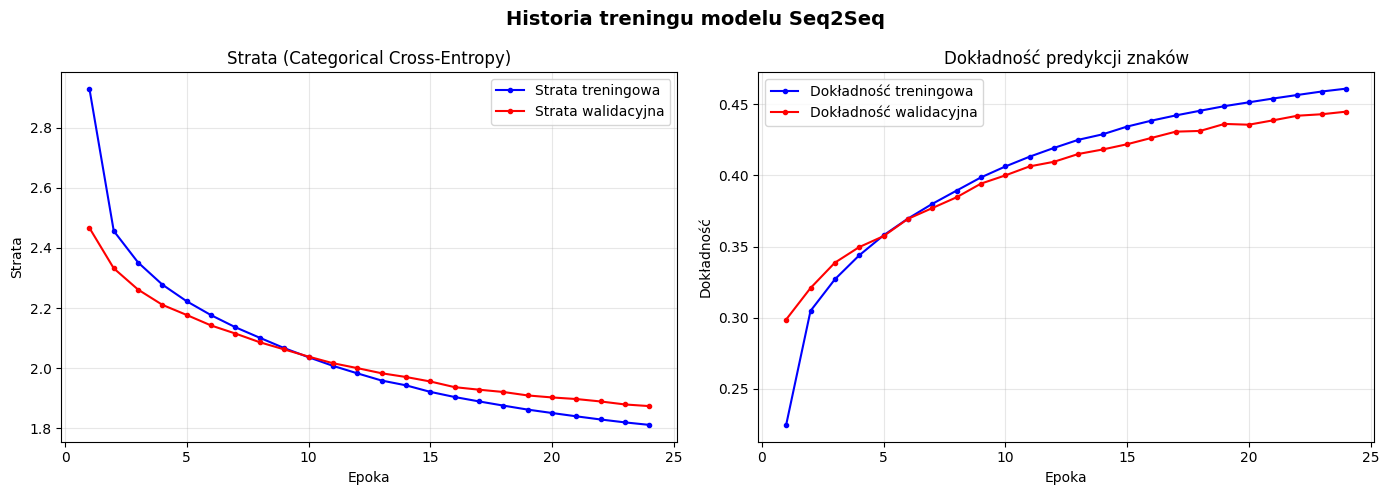

Interpretacja:
  Dok. końcowa (walidacja): 44.5%

  Uwaga: dokładność ~30-40% to DOBRY wynik dla modelu znakowego bez attention.
  Model przewiduje 1 z ~90 możliwych znaków — losowe zgadywanie to ok. 1%.


In [34]:
# ============================================================
# KOMÓRKA 8: Wizualizacja historii treningu
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epoki = range(1, len(historia.history['loss']) + 1)

# Wykres 1: strata (loss)
ax1.plot(epoki, historia.history['loss'],
         'b-o', markersize=3, label='Strata treningowa')
ax1.plot(epoki, historia.history['val_loss'],
         'r-o', markersize=3, label='Strata walidacyjna')
ax1.set_title('Strata (Categorical Cross-Entropy)', fontsize=12)
ax1.set_xlabel('Epoka')
ax1.set_ylabel('Strata')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Wykres 2: dokładność
ax2.plot(epoki, historia.history['accuracy'],
         'b-o', markersize=3, label='Dokładność treningowa')
ax2.plot(epoki, historia.history['val_accuracy'],
         'r-o', markersize=3, label='Dokładność walidacyjna')
ax2.set_title('Dokładność predykcji znaków', fontsize=12)
ax2.set_xlabel('Epoka')
ax2.set_ylabel('Dokładność')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Historia treningu modelu Seq2Seq', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('historia_treningu.png', dpi=150, bbox_inches='tight')
plt.show()

print("Interpretacja:")
print(f"  Dok. końcowa (walidacja): {historia.history['val_accuracy'][-1]:.1%}")
print()
print("  Uwaga: dokładność ~30-40% to DOBRY wynik dla modelu znakowego bez attention.")
print("  Model przewiduje 1 z ~90 możliwych znaków — losowe zgadywanie to ok. 1%.")

---
## 6. Generowanie tekstu

### Próbkowanie z temperaturą

Zamiast zawsze wybierać znak z najwyższym prawdopodobieństwem (*greedy decoding*),
używamy **próbkowania z temperaturą $T$**:

$$P'(z_i) = \frac{\exp\!\left(\tfrac{\log P(z_i)}{T}\right)}{\displaystyle\sum_j \exp\!\left(\tfrac{\log P(z_j)}{T}\right)}$$

| Temperatura $T$ | Zachowanie modelu |
|-----------------|-------------------|
| $T \to 0$ (greedy) | Zawsze wybiera najlepszy znak — deterministyczne, może się zapętlać |
| $T = 0.5$ | Dobra równowaga jakości i różnorodności |
| $T = 1.0$ | Oryginalne prawdopodobieństwa modelu |
| $T > 1.0$ | Bardziej losowe, kreatywne, ale może generować nieistniejące słowa |

In [35]:
# ============================================================
# KOMÓRKA 9: Funkcje generowania tekstu
# ============================================================

def probkuj_z_temperatura(predykcje: np.ndarray, temperatura: float = 1.0) -> int:
    """
    Losuje indeks znaku z rozkładu zmodyfikowanego przez temperaturę.

    Argumenty:
        predykcje:   wektor prawdopodobieństw z warstwy softmax
        temperatura: parametr losowości (mały = deterministyczny, duży = losowy)

    Zwraca:
        indeks wybranego znaku w słowniku
    """
    predykcje = np.asarray(predykcje, dtype=np.float64)

    # Logarytmujemy i skalujemy przez temperaturę
    log_pred = np.log(predykcje + 1e-10) / temperatura

    # Numerycznie stabilna wersja softmax: odejmujemy maksimum przed exp()
    exp_pred = np.exp(log_pred - np.max(log_pred))
    prob = exp_pred / np.sum(exp_pred)

    # Losowanie multinomialne: 1 próba z rozkładu prob
    return np.argmax(np.random.multinomial(1, prob))


def generuj_tekst(
    prompt: str,
    max_dlugosc: int = 200,
    temperatura: float = 0.5
) -> str:
    """
    Generuje kontynuację tekstu na podstawie podanego promptu.

    Argumenty:
        prompt:       tekst wejściowy (optymalne 20-50 znaków)
        max_dlugosc:  maksymalna liczba generowanych znaków
        temperatura:  parametr losowości (0.1-2.0)

    Zwraca:
        wygenerowana kontynuacja (bez promptu)
    """
    if not prompt:
        raise ValueError("Prompt nie może być pusty")

    # Krok 1: Enkodowanie promptu
    # Tworzymy tensor one-hot dla całego promptu
    wejscie_enc = np.zeros(
        (1, len(prompt), ROZMIAR_SLOWNIKA), dtype=np.float32
    )
    for t, znak in enumerate(prompt):
        if znak in znak_na_idx:
            wejscie_enc[0, t, znak_na_idx[znak]] = 1.0
        # Znaki spoza słownika pozostają jako wektor zerowy (bezpieczne pominięcie)

    # Enkoder przetwarza cały prompt i zwraca wektor kontekstu [h, c]
    stany = model_enkoder.predict(wejscie_enc, verbose=0)
    h, c = stany[0], stany[1]

    # Krok 2: Dekodowanie znak po znaku
    # Zaczynamy od tokenu START
    aktualny_znak = np.zeros((1, 1, ROZMIAR_SLOWNIKA), dtype=np.float32)
    aktualny_znak[0, 0, znak_na_idx[ZNAK_START]] = 1.0

    wygenerowany = ''

    for _ in range(max_dlugosc):
        # Jeden krok dekodera: znak + stany → predykcja + nowe stany
        predykcje, h, c = model_dekoder.predict(
            [aktualny_znak, h, c], verbose=0
        )

        # Wybierz kolejny znak (próbkowanie z temperaturą)
        idx = probkuj_z_temperatura(predykcje[0, 0, :], temperatura)
        nowy_znak = idx_na_znak[idx]
        wygenerowany += nowy_znak

        # Zaktualizuj wejście dekodera na następny krok
        aktualny_znak = np.zeros((1, 1, ROZMIAR_SLOWNIKA), dtype=np.float32)
        aktualny_znak[0, 0, idx] = 1.0

    return wygenerowany


print("Funkcje generowania zdefiniowane. Uruchom kolejną komórkę, aby zobaczyć wyniki!")

Funkcje generowania zdefiniowane. Uruchom kolejną komórkę, aby zobaczyć wyniki!


In [36]:
# ============================================================
# KOMÓRKA 9b: Generowanie tekstu — Beam Search
# ============================================================

def generuj_tekst_beam(
    prompt: str,
    max_dlugosc: int = 200,
    num_beams: int = 5,
    length_penalty: float = 1.0
) -> str:
    """
    Generuje kontynuację tekstu używając przeszukiwania wiązkowego (beam search).

    Zamiast losować jeden znak w każdym kroku, utrzymujemy `num_beams`
    najlepszych kandydatów i na końcu zwracamy sekwencję o najwyższym wyniku.

    Argumenty:
        prompt:         tekst wejściowy (optymalne 20–50 znaków)
        max_dlugosc:    maksymalna liczba generowanych znaków
        num_beams:      liczba wiązek (k) — więcej = lepsza jakość, wolniej
        length_penalty: wykładnik normalizacji długości
                        > 1.0 faworyzuje dłuższe sekwencje
                        < 1.0 faworyzuje krótsze sekwencje
                        = 1.0 bez korekty (surowe log-prawdopodobieństwo / długość)

    Zwraca:
        wygenerowana kontynuacja o najwyższym znormalizowanym wyniku
    """
    if not prompt:
        raise ValueError("Prompt nie może być pusty")

    # Krok 1: Enkodowanie promptu → wektor kontekstu [h, c]
    wejscie_enc = np.zeros((1, len(prompt), ROZMIAR_SLOWNIKA), dtype=np.float32)
    for t, znak in enumerate(prompt):
        if znak in znak_na_idx:
            wejscie_enc[0, t, znak_na_idx[znak]] = 1.0

    stany = model_enkoder.predict(wejscie_enc, verbose=0)
    h0, c0 = stany[0], stany[1]   # shape: (1, WYMIAR_UKRYTY)

    # Krok 2: Inicjalizacja wiązek
    # Każda wiązka: (log_prob, tekst, h, c, aktualny_znak_onehot)
    aktualny_znak = np.zeros((1, 1, ROZMIAR_SLOWNIKA), dtype=np.float32)
    aktualny_znak[0, 0, znak_na_idx[ZNAK_START]] = 1.0

    wiazki = [(0.0, '', h0.copy(), c0.copy(), aktualny_znak.copy())]
    ukonczone = []   # wiązki, które osiągnęły ZNAK_STOP

    # Krok 3: Rozszerzanie wiązek krok po kroku
    for _ in range(max_dlugosc):
        if not wiazki:
            break

        kandydaci = []

        for log_prob, tekst, h, c, akt_znak in wiazki:
            # Jeden krok dekodera: znak + stany → rozkład + nowe stany
            predykcje, nowy_h, nowy_c = model_dekoder.predict(
                [akt_znak, h, c], verbose=0
            )
            probs = predykcje[0, 0, :]   # shape: (ROZMIAR_SLOWNIKA,)

            # Weź top-num_beams kandydatów z tego kroku
            top_idx = np.argsort(probs)[-num_beams:]

            for idx in top_idx:
                nowy_znak = idx_na_znak[idx]
                nowy_log_prob = log_prob + np.log(probs[idx] + 1e-10)
                nowy_tekst = tekst + nowy_znak

                nowy_akt = np.zeros((1, 1, ROZMIAR_SLOWNIKA), dtype=np.float32)
                nowy_akt[0, 0, idx] = 1.0

                kandydaci.append((
                    nowy_log_prob,
                    nowy_tekst,
                    nowy_h.copy(),
                    nowy_c.copy(),
                    nowy_akt
                ))

        # Sortuj według wyniku znormalizowanego długością
        kandydaci.sort(
            key=lambda x: x[0] / max(len(x[1]), 1) ** length_penalty,
            reverse=True
        )

        # Rozdziel na ukończone (ZNAK_STOP) i aktywne
        wiazki = []
        for kandydat in kandydaci:
            if len(wiazki) >= num_beams:
                break
            _, tekst_k, *_ = kandydat
            if tekst_k.endswith(ZNAK_STOP):
                ukonczone.append(kandydat)
            else:
                wiazki.append(kandydat)

    # Wybierz najlepszą wiązkę spośród wszystkich
    wszystkie = ukonczone + wiazki
    if not wszystkie:
        return ''

    najlepsza = max(
        wszystkie,
        key=lambda x: x[0] / max(len(x[1]), 1) ** length_penalty
    )
    return najlepsza[1]


print("Funkcja beam search zdefiniowana.")
print("Parametry: num_beams (domyślnie 5), length_penalty (domyślnie 1.0)")

Funkcja beam search zdefiniowana.
Parametry: num_beams (domyślnie 5), length_penalty (domyślnie 1.0)


# ============================================================
# KOMÓRKA 10b: Porównanie beam search vs próbkowanie temperaturą
# ============================================================

PROMPT = "Daj mi wstażkę błękitną oddam ci ją bez opóźnienia"

print("=" * 65)
print(f"PROMPT: {repr(PROMPT)}")
print("=" * 65)

print("\n── Beam Search (num_beams=5, length_penalty=1.0) " + "─" * 15)
np.random.seed(SEED)
tekst_beam = generuj_tekst_beam(PROMPT, max_dlugosc=250, num_beams=5)
print(PROMPT + tekst_beam)

print("\n── Próbkowanie temperaturowe (T=0.5) " + "─" * 25)
np.random.seed(SEED)
tekst_temp = generuj_tekst(PROMPT, max_dlugosc=250, temperatura=0.5)
print(PROMPT + tekst_temp)

print("\n" + "=" * 65)
print("Beam search: deterministyczny, maksymalizuje łączne prawdopodobieństwo")
print("Temperatura: losowy, zróżnicowany styl")

In [37]:
# ============================================================
# KOMÓRKA 10: Przykłady generowania przy różnych temperaturach
# ============================================================

# Klasyczny incipit Pana Tadeusza — dobrze znany punkt odniesienia
PROMPT = "Litwo! Ojczyzno moja! ty jesteś jak zdrowi"

print("=" * 65)
print(f"PROMPT: {repr(PROMPT)}")
print("=" * 65)

for temperatura in [0.2, 0.5, 1.0, 1.5]:
    print(f"\n── Temperatura = {temperatura} " + "─" * 40)
    np.random.seed(SEED)   # resetujemy ziarno dla porównywalności wyników
    tekst = generuj_tekst(PROMPT, max_dlugosc=250, temperatura=temperatura)
    # Wyświetlamy prompt + wygenerowaną kontynuację
    print(PROMPT + tekst)

print("\n" + "=" * 65)
print("Obserwacje:")
print("  T=0.2: zdeterminowany, może się powtarzać")
print("  T=0.5: dobra równowaga jakości i różnorodności")
print("  T=1.0: zgodny z oryginalnym rozkładem modelu")
print("  T=1.5: kreatywny, ale może tworzyć nieistniejące słowa")

PROMPT: 'Litwo! Ojczyzno moja! ty jesteś jak zdrowi'

── Temperatura = 0.2 ────────────────────────────────────────
Litwo! Ojczyzno moja! ty jesteś jak zdrowie — rzekł Atos — jeżeli nie mogła za niej stanie się za niej straszne na przyjaciół.

— O! Nie mogła za niej — rzekła milady — odezwał się do siebie.

— O! Powiedziała milady — odezwał się do Aramis.

— O! Panie — rzekł Atos — i to jesteś za niej sta

── Temperatura = 0.5 ────────────────────────────────────────
Litwo! Ojczyzno moja! ty jesteś jak zdrowie — rzekł Portos — Portos pod Lona, że ta kochanków, jak w obrzyła na stara niebarzacznych siedział na stole i uśmiechnie ukryma i zapełnie się z porzu.

Nazajutrz pod wystał wszystkiego w prokuratora, ba dzień na kardynała i nie ma w rozkazy i widzi

── Temperatura = 1.0 ────────────────────────────────────────
Litwo! Ojczyzno moja! ty jesteś jak zdrowi.

— A! Zatem! A za więk czasu nor…

— Tym razem powieszieć?…

— Oświedzieć na „Przespokoltpie. — Tordziała? — zawołała — pokoju p

In [38]:
# ============================================================
# KOMÓRKA 11: Interaktywna generacja — zmień i eksperymentuj!
# ============================================================

# Zmień poniższe trzy zmienne i uruchom komórkę ponownie
TWOJ_PROMPT      = "Polska jest krajem "   # wpisz własny fragment
TWOJA_TEMPERATURA = 0.1                    # wartości: 0.1 (deterministyczny) do 2.0 (losowy)
TWOJA_DLUGOSC    = 400                     # liczba generowanych znaków

print(f"Prompt:       {repr(TWOJ_PROMPT)}")
print(f"Temperatura:  {TWOJA_TEMPERATURA}")
print("-" * 65)
wynik = generuj_tekst(TWOJ_PROMPT, TWOJA_DLUGOSC, TWOJA_TEMPERATURA)
print(TWOJ_PROMPT + wynik)

Prompt:       'Polska jest krajem '
Temperatura:  0.1
-----------------------------------------------------------------
Polska jest krajem pod siebie — rzekł Atos — i to pod siebie — rzekł Atos — jesteś się za niej stanie się z tego podziewać się za niej stanąć na powiedzieć.

— Tak, tak — rzekł Atos — i to powiedziała milady — odezwał się d'Artagnan.

— Czy to jesteś się na to powiedziała — odezwał się do siebie.

— Czy to jesteś powiedziała — odezwał się d'Artagnan.

— Czy nie mogła za niej — rzekł Atos.

— Czy ty nie mogła milady 


In [39]:
# ============================================================
# KOMÓRKA 12: Zapis modelu na dysk
# ============================================================
# Keras 3 używa formatu .keras (architektura + wagi + konfiguracja kompilacji)

model.save('./model_seq2seq.keras')
model_enkoder.save('./model_enkoder.keras')
model_dekoder.save('./model_dekoder.keras')

print("Zapisano:")
print("  model_seq2seq.keras  — model treningowy (do kontynuowania treningu)")
print("  model_enkoder.keras  — enkoder (do inferencji)")
print("  model_dekoder.keras  — dekoder (do inferencji)")
print()
print("Aby wczytać w nowej sesji:")
print("  model_enkoder = keras.models.load_model('./model_enkoder.keras')")
print("  model_dekoder = keras.models.load_model('./model_dekoder.keras')")

Zapisano:
  model_seq2seq.keras  — model treningowy (do kontynuowania treningu)
  model_enkoder.keras  — enkoder (do inferencji)
  model_dekoder.keras  — dekoder (do inferencji)

Aby wczytać w nowej sesji:
  model_enkoder = keras.models.load_model('./model_enkoder.keras')
  model_dekoder = keras.models.load_model('./model_dekoder.keras')


---
## Podsumowanie

W tym notebooku zbudowaliśmy kompletny potok NLP od surowych danych do działającego modelu:

| Krok | Co zrobiliśmy |
|------|---------------|
| 1 | Wczytaliśmy i oczyściliśmy korpus z Wolnych Lektur |
| 2 | Zbudowaliśmy słownik znaków + kodowanie one-hot |
| 3 | Przygotowaliśmy pary treningowe z **teacher forcing** |
| 4 | Zdefiniowaliśmy enkoder LSTM i dekoder LSTM |
| 5 | Wytrenowaliśmy model z callbackami (EarlyStopping, ReduceLROnPlateau) |
| 6 | Zbudowaliśmy modele inferencyjne reużywające warstw treningowych |
| 7 | Generowaliśmy tekst z **próbkowaniem temperaturowym** |

---

## Ograniczenia modelu znakowego

- **Brak rozumienia semantycznego** — model uczy się statystycznych wzorców sekwencji znaków, nie znaczeń słów
- **Krótki kontekst** — okno 40 znaków ogranicza spójność dłuższych fragmentów
- **Brak mechanizmu uwagi** (*attention*) — enkoder musi kompresować cały kontekst do stałego wektora `[h, c]`

---

## Ćwiczenia

1. **Zmień epokę literacką**: zamień `'Romantyzm'` na `'Pozytywizm'` lub `'Modernizm'` i porównaj styl generacji.

2. **Eksperymentuj z `WYMIAR_UKRYTY`**: sprawdź jak `64` vs `256` wpływa na jakość tekstu i czas treningu.

3. **Zmień `DLUGOSC_SEKWENCJI`**: co się stanie z `SEQ_LEN=20` vs `SEQ_LEN=80`?

4. **Stacked LSTM**: dodaj drugą warstwę LSTM w dekoderze (`return_sequences=True` na pierwszej LSTM).

5. **Beam search**: zamiast próbkowania z temperaturą zaimplementuj przeszukiwanie wiązkowe — utrzymuj `k` najlepszych kandydatów w każdym kroku.

6. **Mechanizm uwagi (Attention)**: rozszerzenie architektury — dekoder może patrzeć wstecz na wszystkie wyjścia enkodera, nie tylko na końcowy stan ukryty.